# Байесовские классификаторы: гауссовский Байес, наивный Байес, дискриминант Фишера

Байесовский подход к классификации: объект $x$ относится к классу с максимальной
апостериорной величиной с учётом штрафов за ошибку $\lambda_c$:

$$a(x) = \arg\max_c \; \Big[ \ln \big(\lambda_c P(c)\big) + \ln p(x \mid c) \Big]$$

Если плотности классов нормальные, $p(x \mid c) = N(\mu_c, \Sigma_c)$, то логарифм
плотности — квадратичная форма, и классификатор сводится к сравнению дискриминантных
функций. Дальше три варианта этой идеи, все реализованы на чистом numpy:

- **гауссовский байесовский классификатор** — у каждого класса своя ковариационная
  матрица, разделяющие границы квадратичные;
- **наивный Байес** — ковариационные матрицы диагональные (признаки считаются
  независимыми);
- **линейный дискриминант Фишера** — ковариационная матрица общая для всех классов,
  квадратичный член сокращается, границы получаются линейными.


## 1. Гауссовский байесовский классификатор (2 класса)

Синтетические данные: два двумерных нормальных распределения по 1000 объектов.
Оцениваю по выборке векторы средних и ковариационные матрицы каждого класса,
а решающее правило строю по логарифму дискриминанты:

$$b(x) = \ln(\lambda P) - \frac{1}{2}(x-\mu)^{\top}\Sigma^{-1}(x-\mu) - \frac{1}{2}\ln|\Sigma|$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# параметры распределений двух классов
r1, D1, mean1 = 0.7, 1.0, [1, -2]
V1 = [[D1, D1 * r1], [D1 * r1, D1]]
r2, D2, mean2 = 0.5, 2.0, [1, 3]
V2 = [[D2, D2 * r2], [D2 * r2, D2]]

# моделирование обучающей выборки
N = 1000
x1 = np.random.multivariate_normal(mean1, V1, N).T
x2 = np.random.multivariate_normal(mean2, V2, N).T

x_train = np.hstack([x1, x2]).T
y_train = np.hstack([np.ones(N) * -1, np.ones(N)])

# оценки математических ожиданий
mm1 = np.mean(x1.T, axis=0)
mm2 = np.mean(x2.T, axis=0)

# оценки ковариационных матриц: центрируем класс и перемножаем матрицы
a = (x1.T - mm1).T
VV1 = a @ a.T / N
a = (x2.T - mm2).T
VV2 = a @ a.T / N

Py1, L1 = 0.5, 1        # априорная вероятность и штраф ошибки первого класса
Py2, L2 = 1 - Py1, 1    # второго


def b(x, mu, L, sigma, Py):
    # логарифм дискриминантной функции гауссовского классификатора
    return (np.log(L * Py)
            - (x - mu).T @ np.linalg.inv(sigma) @ (x - mu) / 2
            - np.log(np.linalg.det(sigma)) / 2)


predict = np.array([
    np.argmax([b(x, mm1, L1, VV1, Py1), b(x, mm2, L2, VV2, Py2)]) * 2 - 1
    for x in x_train
])

errors = np.sum(predict != y_train)
TP = np.sum((predict == 1) & (y_train == 1))
TN = np.sum((predict == -1) & (y_train == -1))
FP = np.sum((predict == 1) & (y_train == -1))
FN = np.sum((predict == -1) & (y_train == 1))
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1 = 2 * precision * recall / (precision + recall)

print(f"ошибок: {errors} из {len(y_train)}")
print(f"accuracy:  {np.mean(predict == y_train):.4f}")
print(f"precision: {precision:.4f}")
print(f"recall:    {recall:.4f}")
print(f"F1:        {f1:.4f}")


ошибок: 4 из 2000
accuracy:  0.9980
precision: 0.9990
recall:    0.9970
F1:        0.9980


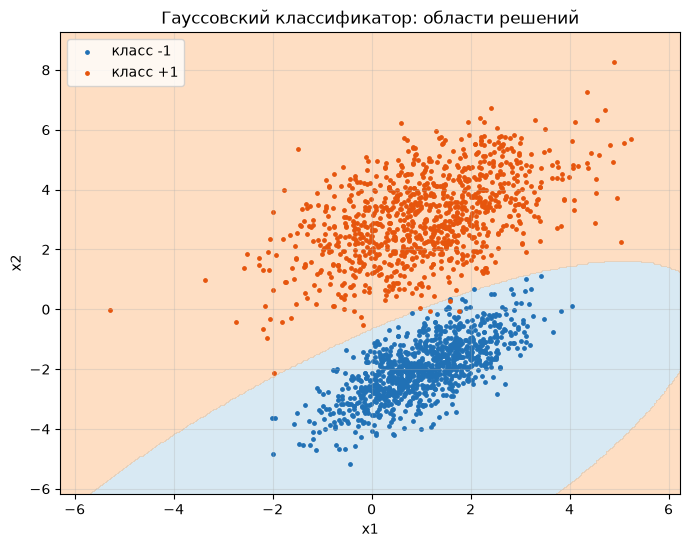

In [2]:
# разделяющая граница: множество точек, где дискриминанты равны
gx = np.linspace(x_train[:, 0].min() - 1, x_train[:, 0].max() + 1, 300)
gy = np.linspace(x_train[:, 1].min() - 1, x_train[:, 1].max() + 1, 300)
G1, G2 = np.meshgrid(gx, gy)
Z = np.zeros(G1.shape)
for i in range(G1.shape[0]):
    for j in range(G1.shape[1]):
        x = np.array([G1[i, j], G2[i, j]])
        Z[i, j] = np.argmax([b(x, mm1, L1, VV1, Py1), b(x, mm2, L2, VV2, Py2)])

plt.figure(figsize=(8, 6))
plt.contourf(G1, G2, Z, levels=[-0.5, 0.5, 1.5], colors=["#9ecae1", "#fdae6b"], alpha=0.4)
neg = y_train == -1
plt.scatter(x_train[neg, 0], x_train[neg, 1], s=6, c="#2171b5", label="класс -1")
plt.scatter(x_train[~neg, 0], x_train[~neg, 1], s=6, c="#e6550d", label="класс +1")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Гауссовский классификатор: области решений")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


Граница получилась кривой (квадратичной) — это следствие разных
ковариационных матриц у классов. Ошибок всего 4 из 2000: облака почти не
перекрываются, и байесовское правило выжимает из данных практически всё.

## 2. Наивный Байес

Данные — те же цветки (100 объектов, 2 признака). «Наивность» в том, что признаки
внутри класса считаются независимыми: ковариационная матрица диагональна, и плотность
распадается в произведение одномерных гауссиан:

$$b(x) = \ln(\lambda P) - \frac{1}{2}\ln\big((2\pi)^d D_1 \ldots D_d\big)
- \sum_{j} \frac{(x_j - \mu_j)^2}{2 D_j}$$


In [3]:
data_x = [(7.2, 2.5), (6.4, 2.2), (6.3, 1.5), (7.7, 2.2), (6.2, 1.8), (5.7, 1.3), (7.1, 2.1), (5.8, 2.4), (5.2, 1.4), (5.9, 1.5), (7.0, 1.4), (6.8, 2.1), (7.2, 1.6), (6.7, 2.4), (6.0, 1.5), (5.1, 1.1), (6.6, 1.3), (6.1, 1.4), (6.7, 2.1), (6.4, 1.8), (5.6, 1.3), (6.9, 2.3), (6.4, 1.9), (6.9, 2.3), (6.5, 2.2), (6.0, 1.5), (5.6, 1.1), (5.6, 1.5), (6.0, 1.0), (6.0, 1.8), (6.7, 2.5), (7.7, 2.3), (5.5, 1.1), (5.8, 1.0), (6.9, 2.1), (6.6, 1.4), (6.3, 1.6), (6.1, 1.4), (5.0, 1.0), (7.7, 2.0), (4.9, 1.7), (7.2, 1.8), (6.8, 1.4), (6.1, 1.2), (5.8, 1.9), (6.3, 2.5), (5.7, 2.0), (6.5, 1.8), (7.6, 2.1), (6.3, 1.5), (6.7, 1.4), (6.4, 2.3), (6.2, 2.3), (6.3, 1.9), (5.5, 1.3), (7.9, 2.0), (6.7, 1.8), (6.4, 1.3), (6.5, 2.0), (6.5, 1.5), (6.9, 1.5), (5.6, 1.3), (5.8, 1.2), (6.7, 2.3), (6.0, 1.6), (5.7, 1.2), (5.7, 1.0), (5.5, 1.0), (6.1, 1.4), (6.3, 1.8), (5.7, 1.3), (6.1, 1.3), (5.5, 1.3), (6.3, 1.3), (5.9, 1.8), (7.7, 2.3), (6.5, 2.0), (5.6, 2.0), (6.7, 1.7), (5.7, 1.3), (5.5, 1.2), (5.0, 1.0), (5.8, 1.9), (6.2, 1.3), (6.2, 1.5), (6.3, 2.4), (6.4, 1.5), (7.4, 1.9), (6.8, 2.3), (5.6, 1.3), (5.8, 1.2), (7.3, 1.8), (6.7, 1.5), (6.3, 1.8), (6.0, 1.6), (6.4, 2.1), (6.1, 1.8), (5.9, 1.8), (5.4, 1.5), (4.9, 1.0)]
data_y = [1, 1, 1, 1, 1, -1, 1, 1, -1, -1, -1, 1, 1, 1, -1, -1, -1, 1, 1, 1, -1, 1, 1, 1, 1, 1, -1, -1, -1, 1, 1, 1, -1, -1, 1, -1, -1, -1, -1, 1, 1, 1, -1, -1, 1, 1, 1, 1, 1, -1, -1, 1, 1, 1, -1, 1, 1, -1, 1, -1, -1, -1, -1, 1, -1, -1, -1, -1, -1, 1, -1, -1, -1, -1, 1, 1, 1, 1, -1, -1, -1, -1, 1, -1, -1, 1, -1, 1, 1, -1, -1, 1, -1, 1, -1, 1, 1, -1, -1, -1]

x_train_nb = np.array(data_x)
y_train_nb = np.array(data_y)


In [4]:
# средние и дисперсии по каждому признаку внутри каждого класса
mx11, mx12 = np.mean(x_train_nb[y_train_nb == -1], axis=0)   # класс -1
mx21, mx22 = np.mean(x_train_nb[y_train_nb == 1], axis=0)    # класс +1

Dx11, Dx12 = np.var(x_train_nb[y_train_nb == -1], axis=0)
Dx21, Dx22 = np.var(x_train_nb[y_train_nb == 1], axis=0)

lm1, lm2 = 1, 1      # штрафы за ошибку
P1, P2 = 0.5, 0.5    # априорные вероятности


def score_minus1(x):
    return (np.log(P1 * lm1)
            - 0.5 * np.log(2 * np.pi * Dx11 * Dx12)
            - (x[0] - mx11) ** 2 / (2 * Dx11)
            - (x[1] - mx12) ** 2 / (2 * Dx12))


def score_plus1(x):
    return (np.log(P2 * lm2)
            - 0.5 * np.log(2 * np.pi * Dx21 * Dx22)
            - (x[0] - mx21) ** 2 / (2 * Dx21)
            - (x[1] - mx22) ** 2 / (2 * Dx22))


predict_nb = np.array([
    np.argmax([score_minus1(x), score_plus1(x)]) * 2 - 1
    for x in x_train_nb
])

error_rate = np.mean(predict_nb != y_train_nb)
TP = np.sum((predict_nb == 1) & (y_train_nb == 1))
TN = np.sum((predict_nb == -1) & (y_train_nb == -1))
FP = np.sum((predict_nb == 1) & (y_train_nb == -1))
FN = np.sum((predict_nb == -1) & (y_train_nb == 1))
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1 = 2 * precision * recall / (precision + recall)

print(f"доля ошибок: {error_rate:.4f}")
print(f"accuracy:  {1 - error_rate:.4f}")
print(f"precision: {precision:.4f}")
print(f"recall:    {recall:.4f}")
print(f"F1:        {f1:.4f}")


доля ошибок: 0.0600
accuracy:  0.9400
precision: 0.9583
recall:    0.9200
F1:        0.9388


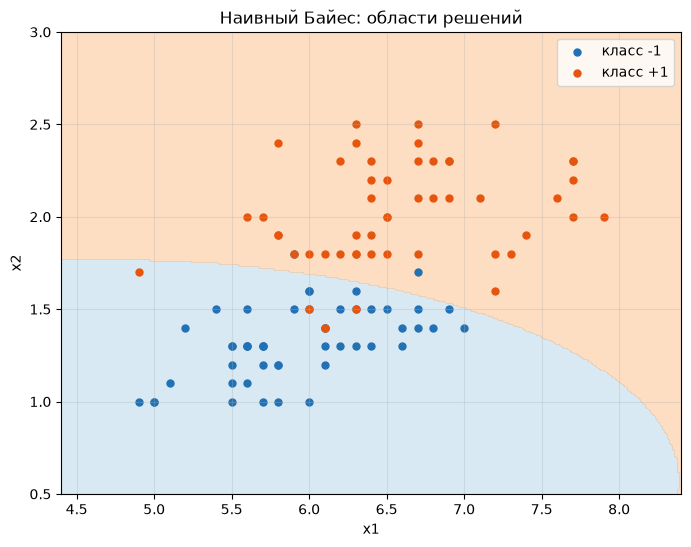

In [5]:
gx = np.linspace(x_train_nb[:, 0].min() - 0.5, x_train_nb[:, 0].max() + 0.5, 250)
gy = np.linspace(x_train_nb[:, 1].min() - 0.5, x_train_nb[:, 1].max() + 0.5, 250)
G1, G2 = np.meshgrid(gx, gy)
Z = np.zeros(G1.shape)
for i in range(G1.shape[0]):
    for j in range(G1.shape[1]):
        x = np.array([G1[i, j], G2[i, j]])
        Z[i, j] = np.argmax([score_minus1(x), score_plus1(x)])

plt.figure(figsize=(8, 6))
plt.contourf(G1, G2, Z, levels=[-0.5, 0.5, 1.5], colors=["#9ecae1", "#fdae6b"], alpha=0.4)
neg = y_train_nb == -1
plt.scatter(x_train_nb[neg, 0], x_train_nb[neg, 1], s=25, c="#2171b5", label="класс -1")
plt.scatter(x_train_nb[~neg, 0], x_train_nb[~neg, 1], s=25, c="#e6550d", label="класс +1")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Наивный Байес: области решений")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


Граница наивного Байеса всегда квадратичная, но из-за диагональности
ковариаций её ориентация привязана к осям признаков. На этих данных классы вытянуты
вдоль осей, так что штраф за «наивность» небольшой: accuracy 0.94, а precision
и recall сбалансированы (0.96 и 0.92).

## 3. Линейный дискриминант Фишера

Если считать ковариационные матрицы классов одинаковыми ($\Sigma_1 = \Sigma_2 = \Sigma$),
квадратичный член в дискриминантах сокращается, и остаётся линейное правило:

$$b(x) = \ln(\lambda P) - \frac{1}{2}\mu^{\top}\Sigma^{-1}\mu + x^{\top}\Sigma^{-1}\mu$$

Данные: два нормальных класса с общей ковариационной матрицей, которую я оцениваю
по объединённой центрированной выборке.


In [6]:
np.random.seed(0)

# параметры распределений: средние разные, ковариация общая
mean1_f, mean2_f = [1, -2], [1, 3]
r, D = 0.7, 2.0
V = [[D, D * r], [D * r, D]]

N = 1000
x1 = np.random.multivariate_normal(mean1_f, V, N).T
x2 = np.random.multivariate_normal(mean2_f, V, N).T

x_train_f = np.hstack([x1, x2]).T
y_train_f = np.hstack([np.ones(N) * -1, np.ones(N)])

mm1 = np.mean(x1.T, axis=0)
mm2 = np.mean(x2.T, axis=0)

# общая ковариационная матрица по центрированным объектам обоих классов
a = np.hstack([(x1.T - mm1).T, (x2.T - mm2).T])
VV = a @ a.T / (2 * N)

Py1 = Py2 = 0.5
L1 = L2 = 1


def b_fisher(Py, L, x, mm, sigma):
    # линейная дискриминантная функция Фишера
    return (np.log(L * Py)
            - mm.T @ np.linalg.inv(sigma) @ mm / 2
            + x.T @ np.linalg.inv(sigma) @ mm)


predict_f = np.array([
    np.argmax([b_fisher(Py1, L1, x, mm1, VV),
               b_fisher(Py2, L2, x, mm2, VV)]) * 2 - 1
    for x in x_train_f
])

errors_f = np.sum(predict_f != y_train_f)
print(f"ошибок: {errors_f} из {len(y_train_f)}")
print(f"accuracy: {np.mean(predict_f == y_train_f):.4f}")


ошибок: 8 из 2000
accuracy: 0.9960


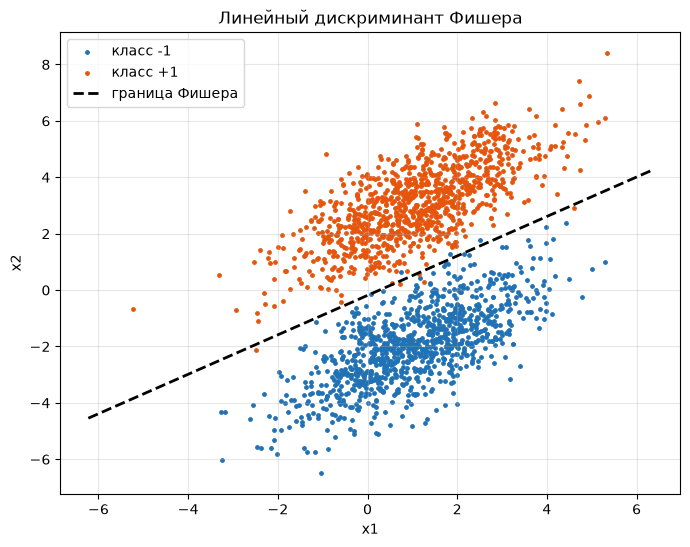

In [7]:
plt.figure(figsize=(8, 6))
neg = y_train_f == -1
plt.scatter(x_train_f[neg, 0], x_train_f[neg, 1], s=6, c="#2171b5", label="класс -1")
plt.scatter(x_train_f[~neg, 0], x_train_f[~neg, 1], s=6, c="#e6550d", label="класс +1")

# граница Фишера — прямая: b1(x) = b2(x)
# при равных P и L это x^T VV^{-1} (mm2 - mm1) = (mm2^T VV^{-1} mm2 - mm1^T VV^{-1} mm1)/2
VV_inv = np.linalg.inv(VV)
w_dir = VV_inv @ (mm2 - mm1)
offset = (mm2.T @ VV_inv @ mm2 - mm1.T @ VV_inv @ mm1) / 2
x_line = np.linspace(x_train_f[:, 0].min() - 1, x_train_f[:, 0].max() + 1, 100)
plt.plot(x_line, (offset - w_dir[0] * x_line) / w_dir[1], "k--", lw=2,
         label="граница Фишера")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Линейный дискриминант Фишера")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


Граница действительно линейная, и для данных с общей ковариацией
это правильный ответ: ошибок всего 8 из 2000 — почти столько же, сколько у
квадратичного байеса из первого раздела (4), а модель проще и устойчивее
к шуму в оценках.

## 4. Те же классификаторы в трёхмерном пространстве

Проверка, что формулы не привязаны к двумерию: те же гауссовский классификатор и
дискриминант Фишера, но признаков три. Для Фишера в исходной работе были посчитаны
только коэффициенты $\alpha = \Sigma^{-1}\mu$ и
$\beta = \ln(\lambda P) - \mu^{\top}\Sigma^{-1}\mu / 2$ — здесь я довёл задачу до
предсказаний и метрик.


In [8]:
np.random.seed(0)

# трёхмерные гауссовы классы со своими ковариационными матрицами
r1, D1, mean1_3d = 0.7, 1.0, [-1, -2, -1]
V1_3d = [[D1, D1 * r1, D1 * r1 * r1], [D1 * r1, D1, D1 * r1], [D1 * r1 * r1, D1 * r1, D1]]
r2, D2, mean2_3d = 0.5, 2.0, [1, 2, 1]
V2_3d = [[D2, D2 * r2, D2 * r2 * r2], [D2 * r2, D2, D2 * r2], [D2 * r2 * r2, D2 * r2, D2]]

N = 1000
x1_3d = np.random.multivariate_normal(mean1_3d, V1_3d, N).T
x2_3d = np.random.multivariate_normal(mean2_3d, V2_3d, N).T
x_train_3d = np.hstack([x1_3d, x2_3d]).T
y_train_3d = np.hstack([np.ones(N) * -1, np.ones(N)])

mm1_3d = np.mean(x1_3d.T, axis=0)
mm2_3d = np.mean(x2_3d.T, axis=0)
VV1_3d = ((x1_3d.T - mm1_3d).T) @ ((x1_3d.T - mm1_3d).T).T / N
VV2_3d = ((x2_3d.T - mm2_3d).T) @ ((x2_3d.T - mm2_3d).T).T / N

predict_3d = np.array([
    np.argmax([b(x, mm1_3d, 1, VV1_3d, 0.5), b(x, mm2_3d, 1, VV2_3d, 0.5)]) * 2 - 1
    for x in x_train_3d
])
print(f"гауссовский классификатор 3D: ошибок {np.sum(predict_3d != y_train_3d)} "
      f"из {len(y_train_3d)}, accuracy {np.mean(predict_3d == y_train_3d):.4f}")


гауссовский классификатор 3D: ошибок 78 из 2000, accuracy 0.9610


In [9]:
np.random.seed(0)

# те же классы, но с общей ковариацией — вариант для Фишера
mean1_f3, mean2_f3 = np.array([1, -2, 0]), np.array([1, 3, 1])
r, D = 0.7, 2.0
V3 = [[D, D * r, D * r * r], [D * r, D, D * r], [D * r * r, D * r, D]]

x1_f3 = np.random.multivariate_normal(mean1_f3, V3, N).T
x2_f3 = np.random.multivariate_normal(mean2_f3, V3, N).T
x_train_f3 = np.hstack([x1_f3, x2_f3]).T
y_train_f3 = np.hstack([np.zeros(N), np.ones(N)])

mm1_f3 = np.mean(x1_f3.T, axis=0)
mm2_f3 = np.mean(x2_f3.T, axis=0)
a3 = np.hstack([(x1_f3.T - mm1_f3).T, (x2_f3.T - mm2_f3).T])
VV_f3 = a3 @ a3.T / (2 * N)

# коэффициенты линейных дискриминантов: b(x) = x^T alpha + beta
alpha1 = np.linalg.inv(VV_f3) @ mm1_f3
alpha2 = np.linalg.inv(VV_f3) @ mm2_f3
beta1 = np.log(1 * 0.5) - mm1_f3.T @ np.linalg.inv(VV_f3) @ mm1_f3 / 2
beta2 = np.log(1 * 0.5) - mm2_f3.T @ np.linalg.inv(VV_f3) @ mm2_f3 / 2

predict_f3 = np.array([
    np.argmax([x @ alpha1 + beta1, x @ alpha2 + beta2])
    for x in x_train_f3
])
print(f"дискриминант Фишера 3D: ошибок {np.sum(predict_f3 != y_train_f3)} "
      f"из {len(y_train_f3)}, accuracy {np.mean(predict_f3 == y_train_f3):.4f}")


дискриминант Фишера 3D: ошибок 4 из 2000, accuracy 0.9980


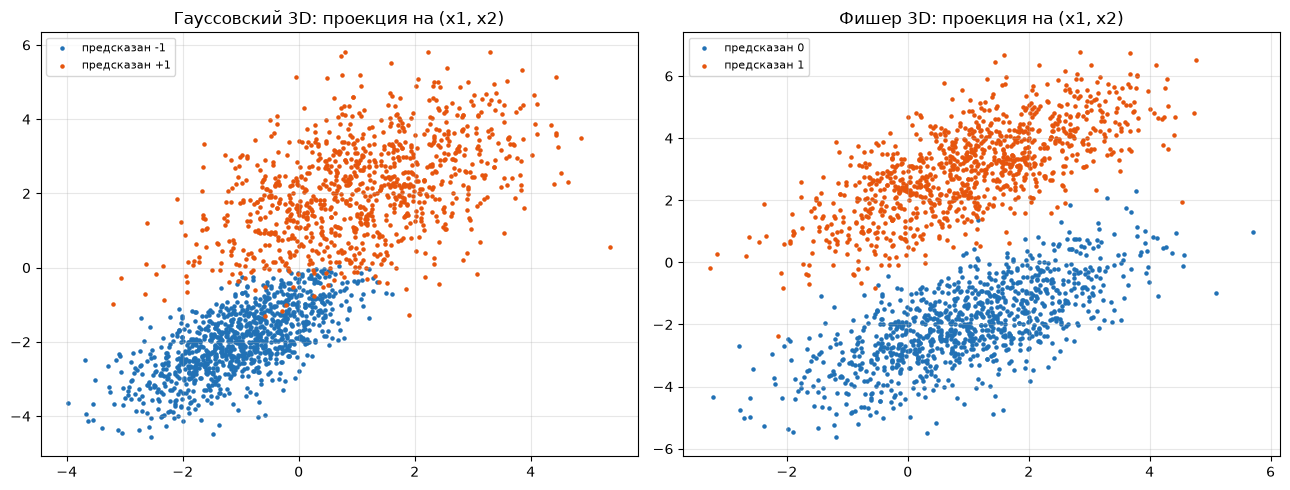

In [10]:
# проекции 3D-выборок на первые два признака с предсказанными метками
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

neg3 = predict_3d == -1
ax[0].scatter(x_train_3d[neg3, 0], x_train_3d[neg3, 1], s=5, c="#2171b5",
              label="предсказан -1")
ax[0].scatter(x_train_3d[~neg3, 0], x_train_3d[~neg3, 1], s=5, c="#e6550d",
              label="предсказан +1")
ax[0].set_title("Гауссовский 3D: проекция на (x1, x2)")
ax[0].legend(fontsize=8)
ax[0].grid(alpha=0.3)

negf = predict_f3 == 0
ax[1].scatter(x_train_f3[negf, 0], x_train_f3[negf, 1], s=5, c="#2171b5",
              label="предсказан 0")
ax[1].scatter(x_train_f3[~negf, 0], x_train_f3[~negf, 1], s=5, c="#e6550d",
              label="предсказан 1")
ax[1].set_title("Фишер 3D: проекция на (x1, x2)")
ax[1].legend(fontsize=8)
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 5. Многоклассовая классификация (3 класса)

Байесовское правило обобщается без изменений: считаем дискриминанту каждого класса
и берём argmax. Сначала дискриминант Фишера с общей ковариацией, затем полный
гауссовский классификатор со своими матрицами. Априорные вероятности теперь
неодинаковые: $P = (0.2, 0.4, 0.4)$ для Фишера и $(0.2, 0.5, 0.3)$ для гауссовского.


In [11]:
np.random.seed(0)

mean1_m = np.array([1, -2])
mean2_m = np.array([-3, -1])
mean3_m = np.array([1, 2])
r, D = 0.5, 1.0
V_m = [[D, D * r], [D * r, D]]

N = 1000
x1_m = np.random.multivariate_normal(mean1_m, V_m, N).T
x2_m = np.random.multivariate_normal(mean2_m, V_m, N).T
x3_m = np.random.multivariate_normal(mean3_m, V_m, N).T

x_train_m = np.hstack([x1_m, x2_m, x3_m]).T
y_train_m = np.hstack([np.zeros(N), np.ones(N), np.ones(N) * 2])

mm1_m = np.mean(x1_m.T, axis=0)
mm2_m = np.mean(x2_m.T, axis=0)
mm3_m = np.mean(x3_m.T, axis=0)

# общая ковариационная матрица по трём классам
a_m = np.hstack([(x1_m.T - mm1_m).T, (x2_m.T - mm2_m).T, (x3_m.T - mm3_m).T])
VV_m = a_m @ a_m.T / (3 * N)

Py = (0.2, 0.4, 0.4)
mms = (mm1_m, mm2_m, mm3_m)
alphas = [np.linalg.inv(VV_m) @ mm for mm in mms]
betas = [np.log(Py[i]) - mms[i].T @ np.linalg.inv(VV_m) @ mms[i] / 2
         for i in range(3)]

predict_m = np.array([
    np.argmax([x @ alphas[i] + betas[i] for i in range(3)])
    for x in x_train_m
])

errors_m = np.sum(predict_m != y_train_m)
print(f"Фишер, 3 класса: ошибок {errors_m} из {len(y_train_m)}, "
      f"accuracy {np.mean(predict_m == y_train_m):.4f}")


Фишер, 3 класса: ошибок 60 из 3000, accuracy 0.9800


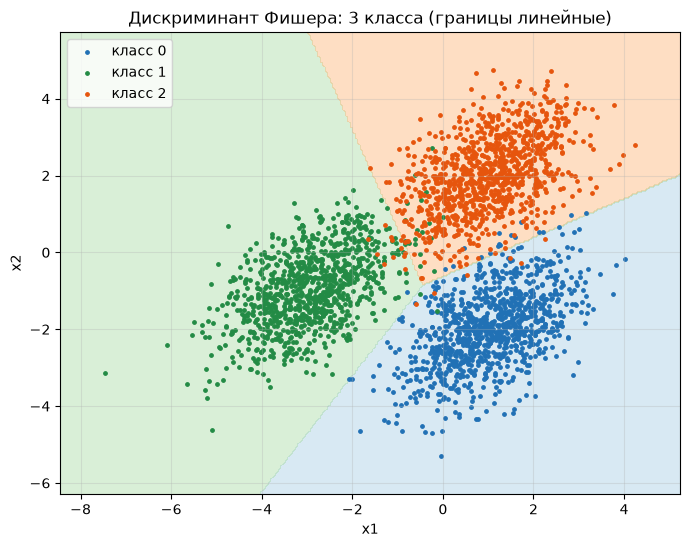

In [12]:
gx = np.linspace(x_train_m[:, 0].min() - 1, x_train_m[:, 0].max() + 1, 250)
gy = np.linspace(x_train_m[:, 1].min() - 1, x_train_m[:, 1].max() + 1, 250)
G1, G2 = np.meshgrid(gx, gy)
Z = np.zeros(G1.shape)
for i in range(G1.shape[0]):
    for j in range(G1.shape[1]):
        x = np.array([G1[i, j], G2[i, j]])
        Z[i, j] = np.argmax([x @ alphas[c] + betas[c] for c in range(3)])

plt.figure(figsize=(8, 6))
plt.contourf(G1, G2, Z, levels=[-0.5, 0.5, 1.5, 2.5],
             colors=["#9ecae1", "#a1d99b", "#fdae6b"], alpha=0.4)
colors = ["#2171b5", "#238b45", "#e6550d"]
for c in range(3):
    pts = x_train_m[y_train_m == c]
    plt.scatter(pts[:, 0], pts[:, 1], s=6, c=colors[c], label=f"класс {c}")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Дискриминант Фишера: 3 класса (границы линейные)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [13]:
# теперь полный гауссовский классификатор со своими ковариациями
np.random.seed(0)

r1, D1, m1 = 0.7, 3.0, [1, -2]
V1_g = [[D1, D1 * r1], [D1 * r1, D1]]
r2, D2, m2 = 0.5, 2.0, [-3, -1]
V2_g = [[D2, D2 * r2], [D2 * r2, D2]]
r3, D3, m3 = 0.3, 1.0, [1, 2]
V3_g = [[D3, D3 * r3], [D3 * r3, D3]]

x1_g = np.random.multivariate_normal(m1, V1_g, N).T
x2_g = np.random.multivariate_normal(m2, V2_g, N).T
x3_g = np.random.multivariate_normal(m3, V3_g, N).T
x_train_g = np.hstack([x1_g, x2_g, x3_g]).T
y_train_g = np.hstack([np.zeros(N), np.ones(N), np.ones(N) * 2])

mms_g, VVs_g = [], []
for xg in (x1_g, x2_g, x3_g):
    mm = np.mean(xg.T, axis=0)
    ac = (xg.T - mm).T
    mms_g.append(mm)
    VVs_g.append(ac @ ac.T / N)

Py_g = (0.2, 0.5, 0.3)
predict_g = np.array([
    np.argmax([b(x, mms_g[c], 1, VVs_g[c], Py_g[c]) for c in range(3)])
    for x in x_train_g
])

errors_g = np.sum(predict_g != y_train_g)
print(f"гауссовский, 3 класса: ошибок {errors_g} из {len(y_train_g)}, "
      f"accuracy {np.mean(predict_g == y_train_g):.4f}")

# матрица ошибок 3x3
cm = np.zeros((3, 3), dtype=int)
for t, p in zip(y_train_g.astype(int), predict_g):
    cm[t, p] += 1
print("матрица ошибок (строки — истина, столбцы — предсказание):")
print(cm)


гауссовский, 3 класса: ошибок 189 из 3000, accuracy 0.9370
матрица ошибок (строки — истина, столбцы — предсказание):
[[916  39  45]
 [  9 961  30]
 [ 29  37 934]]


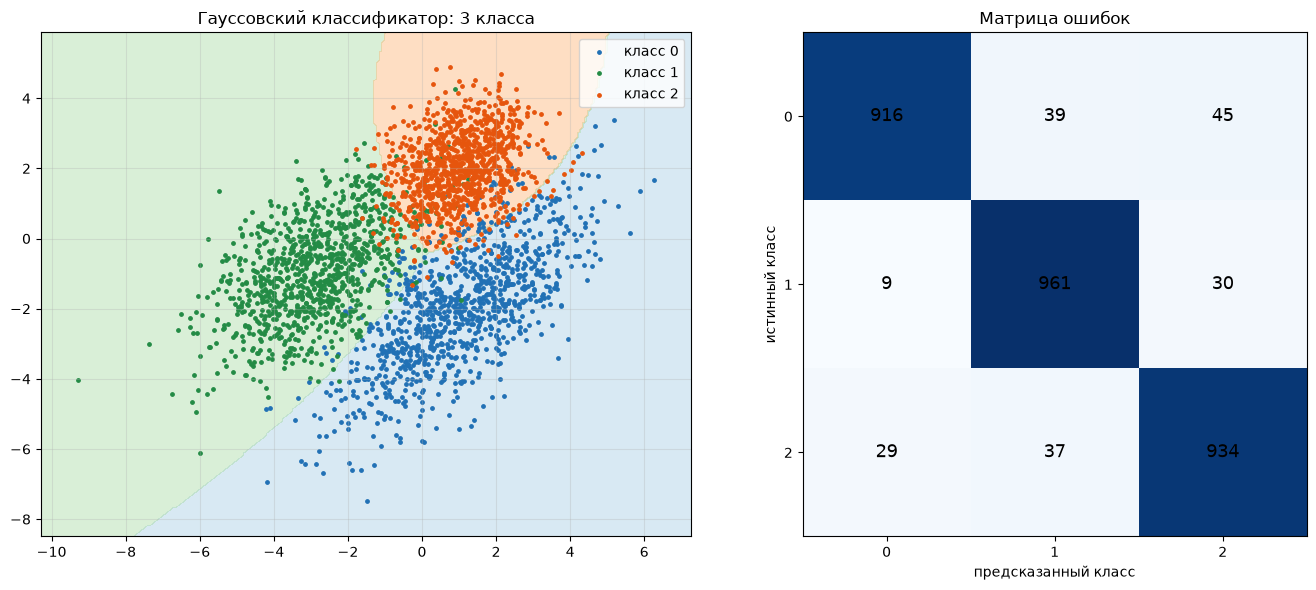

In [14]:
gx = np.linspace(x_train_g[:, 0].min() - 1, x_train_g[:, 0].max() + 1, 250)
gy = np.linspace(x_train_g[:, 1].min() - 1, x_train_g[:, 1].max() + 1, 250)
G1, G2 = np.meshgrid(gx, gy)
Z = np.zeros(G1.shape)
for i in range(G1.shape[0]):
    for j in range(G1.shape[1]):
        x = np.array([G1[i, j], G2[i, j]])
        Z[i, j] = np.argmax([b(x, mms_g[c], 1, VVs_g[c], Py_g[c]) for c in range(3)])

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

ax[0].contourf(G1, G2, Z, levels=[-0.5, 0.5, 1.5, 2.5],
               colors=["#9ecae1", "#a1d99b", "#fdae6b"], alpha=0.4)
for c in range(3):
    pts = x_train_g[y_train_g == c]
    ax[0].scatter(pts[:, 0], pts[:, 1], s=6, c=colors[c], label=f"класс {c}")
ax[0].set_title("Гауссовский классификатор: 3 класса")
ax[0].legend()
ax[0].grid(alpha=0.3)

im = ax[1].imshow(cm, cmap="Blues")
for i in range(3):
    for j in range(3):
        ax[1].text(j, i, cm[i, j], ha="center", va="center", fontsize=13)
ax[1].set_xticks([0, 1, 2])
ax[1].set_yticks([0, 1, 2])
ax[1].set_xlabel("предсказанный класс")
ax[1].set_ylabel("истинный класс")
ax[1].set_title("Матрица ошибок")

plt.tight_layout()
plt.show()


## Выводы

- Байесовское правило с нормальными плотностями даёт рабочий классификатор буквально
  из оценок средних и ковариаций — никакого итеративного обучения не нужно.
- Разные ковариации у классов → квадратичные границы; общая ковариация (Фишер) →
  линейные. Фишер устойчивее при малых выборках (меньше параметров оценивать),
  гауссовский вариант гибче, когда ковариации правда разные.
- Наивный Байес проигрывает совсем немного, зато оценивает всего $2d$ параметров
  на класс и потому почти не переобучается.
- Метрики везде посчитаны полностью: accuracy, precision/recall/F1 для двух классов
  и матрица ошибок для трёх. Основная масса ошибок — в зоне перекрытия облаков,
  куда без байесовской ошибки не проникнуть никакому классификатору.
- Неодинаковые априорные вероятности заметно двигают границы: класс с бо́льшим $P$
  «забирает» себе часть пограничной зоны.
